# Sesión 3 — Texto
## NLP básico
Objetivo

Preprocesamiento + wordcloud + sentimientos

### Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from wordcloud import WordCloud

In [2]:
!pip install -q sentence-transformers umap-learn hdbscan

In [3]:
!pip install pandas scikit-learn nltk xgboost shap

In [4]:
# instalar spaCy + modelo en español
!pip install -q spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 34.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
# Descargar TODO lo necesario (evita errores en vivo)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
!pip install pysentimiento

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.0 MB/s eta 0:00:00


### Nivel Fundamental

In [33]:
# dataset sintético de textos
textos = [
    "La educación en el Perú es desigual",
    "Me encanta la literatura latinoamericana",
    "El sistema político genera frustración",
    "La cultura es diversa y rica",
    "La economía afecta a todos"
]

df = pd.DataFrame({"texto": textos})
df

,texto
0,La educación en el Perú es desigual
1,Me encanta la literatura latinoamericana
2,El sistema político genera frustración
3,La cultura es diversa y rica
4,La economía afecta a todos


# 1. TOKENIZACIÓN
Un token es la unidad mínima significativa en la que se divide un texto para su procesamiento.

In [34]:
# ===== 1. TOKENIZACIÓN =====
df["tokens"] = df["texto"].apply(lambda x: word_tokenize(x.lower(), language='spanish'))

df

,texto,tokens
0,La educación en el Perú es desigual,"[la, educación, en, el, perú, es, desigual]"
1,Me encanta la literatura latinoamericana,"[me, encanta, la, literatura, latinoamericana]"
2,El sistema político genera frustración,"[el, sistema, político, genera, frustración]"
3,La cultura es diversa y rica,"[la, cultura, es, diversa, y, rica]"
4,La economía afecta a todos,"[la, economía, afecta, a, todos]"


# 2. STOPWORDS
Las stopwords (o palabras vacías) son palabras muy comunes en un idioma que aportan poco significado semántico y generalmente se eliminan en el procesamiento de texto porque no ayudan a diferenciar documentos o a entender el contenido principal.

In [35]:
# ===== 2. STOPWORDS =====
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('spanish'))

df["tokens_limpios"] = df["tokens"].apply(
    lambda palabras: [w for w in palabras if w not in stop_words]
)

df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,texto,tokens,tokens_limpios
0,La educación en el Perú es desigual,"[la, educación, en, el, perú, es, desigual]","[educación, perú, desigual]"
1,Me encanta la literatura latinoamericana,"[me, encanta, la, literatura, latinoamericana]","[encanta, literatura, latinoamericana]"
2,El sistema político genera frustración,"[el, sistema, político, genera, frustración]","[sistema, político, genera, frustración]"
3,La cultura es diversa y rica,"[la, cultura, es, diversa, y, rica]","[cultura, diversa, rica]"
4,La economía afecta a todos,"[la, economía, afecta, a, todos]","[economía, afecta]"


# 3. WORDCLOUD
Una WordCloud es una visualización gráfica donde las palabras aparecen con diferentes tamaños. A mayor frecuencia de una palabra en el texto, más grande y prominente se muestra en la nube.

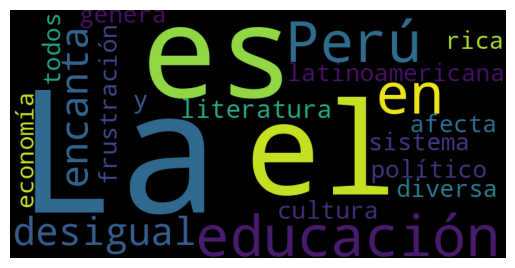

In [36]:
# ===== 3. WORDCLOUD =====

texto_total = " ".join(df["texto"])
#tokens_limpios

wc = WordCloud(width=800, height=400).generate(texto_total)

plt.imshow(wc)
plt.axis("off")
plt.show()

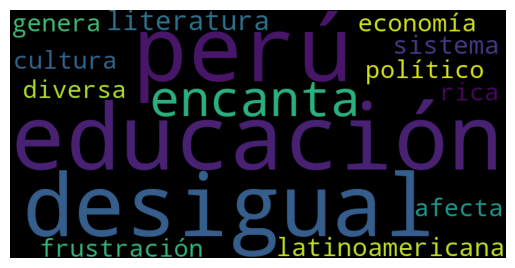

In [37]:
# ===== 3. WORDCLOUD SIN STOPWORDS =====

# Unir los tokens limpios (sin stopwords) en un solo string
texto_total_limpio = " ".join([" ".join(tokens) for tokens in df["tokens_limpios"]])

# Crear y mostrar la WordCloud
wc = WordCloud(width=800, height=400).generate(texto_total_limpio)

plt.imshow(wc)
plt.axis("off")
plt.show()

# 4. Análisis de sentimientos
El análisis de sentimientos es una técnica que clasifica automáticamente un texto según la carga emocional o actitud que expresa (positiva, negativa o neutral).

In [10]:
# ===== 4. SENTIMIENTOS =====
from pysentimiento import create_analyzer

analyzer = create_analyzer(task="sentiment", lang="es")

df["sentimiento"] = df["texto"].apply(lambda x: analyzer.predict(x).output)

df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

,texto,tokens,tokens_limpios,sentimiento
0,La educación en el Perú es desigual,"[la, educación, en, el, perú, es, desigual]","[educación, perú, desigual]",NEG
1,Me encanta la literatura latinoamericana,"[me, encanta, la, literatura, latinoamericana]","[encanta, literatura, latinoamericana]",POS
2,El sistema político genera frustración,"[el, sistema, político, genera, frustración]","[sistema, político, genera, frustración]",NEG
3,La cultura es diversa y rica,"[la, cultura, es, diversa, y, rica]","[cultura, diversa, rica]",POS
4,La economía afecta a todos,"[la, economía, afecta, a, todos]","[economía, afecta]",NEG


In [11]:
# ===== EJERCICIO =====
# 1. Agregar más textos
# 2. Ver palabras más frecuentes
# 3. Analizar sentimientos

In [ ]:
'''
import pandas as pd

# Dataset sintético de 25 textos
textos = [
    # EDUCACIÓN (5)
    "La educación en el Perú es desigual y necesita reformas urgentes",
    "La calidad educativa mejora con inversión en docentes",
    "El acceso a la universidad pública es limitado para estudiantes de bajos recursos",
    "La pandemia afectó gravemente el aprendizaje de los niños",
    "La tecnología en las aulas puede reducir la brecha educativa",

    # LITERATURA (3)
    "Me encanta la literatura latinoamericana por su realismo mágico",
    "Gabriel García Márquez es un autor fundamental del realismo mágico",
    "La poesía de Pablo Neruda emociona a lectores de todo el mundo",

    # POLÍTICA (4)
    "El sistema político genera frustración y desconfianza ciudadana",
    "La corrupción en el gobierno afecta la credibilidad democrática",
    "La participación ciudadana fortalece la democracia",
    "Las reformas políticas son necesarias para mejorar la gobernabilidad",

    # CULTURA (3)
    "La cultura peruana es diversa y rica en tradiciones ancestrales",
    "La gastronomía peruana es reconocida mundialmente",
    "Las festividades religiosas reflejan el sincretismo cultural",

    # ECONOMÍA (3)
    "La economía informal afecta la recaudación tributaria",
    "El crecimiento económico depende de la inversión extranjera",
    "La inflación reduce el poder adquisitivo de las familias",

    # SALUD (2)
    "La atención médica debe ser universal y gratuita",
    "La salud mental requiere mayor atención durante la crisis",

    # TECNOLOGÍA (2)
    "La inteligencia artificial transformará el mercado laboral",
    "El acceso a internet es un derecho fundamental en el siglo XXI",

    # MEDIO AMBIENTE (2)
    "El cambio climático amenaza la biodiversidad amazónica",
    "La deforestación aumenta las emisiones de carbono",

    # DEPORTES (1)
    "El deporte promueve la salud física y mental"
]

df = pd.DataFrame({"texto": textos})
print(f"Dataset creado con {len(df)} textos")
print("\nPRIMEROS 5 TEXTOS:")
print(df.head())
print("\nESTADÍSTICAS:")
print(f"Longitud promedio: {df['texto'].str.len().mean():.0f} caracteres")
print(f"Mínimo: {df['texto'].str.len().min()} caracteres")
print(f"Máximo: {df['texto'].str.len().max()} caracteres")
'''

# NIVEL BÁSICO

# Lematización
Un lemma es la forma canónica o raíz conceptual de una palabra, es decir, la palabra en su forma base de diccionario, sin conjugaciones, género, número o variaciones derivativas.

In [12]:
###===== 5. NORMALIZACIÓN (LEMMA) =====

# cargar modelo
nlp = spacy.load("es_core_news_sm")

def lemmatize(texto):
    doc = nlp(texto)
    return [token.lemma_ for token in doc
            if not token.is_stop and token.is_alpha]

df["lemmas"] = df["texto"].apply(lemmatize)

df

,texto,tokens,tokens_limpios,sentimiento,lemmas
0,La educación en el Perú es desigual,"[la, educación, en, el, perú, es, desigual]","[educación, perú, desigual]",NEG,"[educación, Perú, desigual]"
1,Me encanta la literatura latinoamericana,"[me, encanta, la, literatura, latinoamericana]","[encanta, literatura, latinoamericana]",POS,"[encantar, literatura, latinoamericano]"
2,El sistema político genera frustración,"[el, sistema, político, genera, frustración]","[sistema, político, genera, frustración]",NEG,"[sistema, político, generar, frustración]"
3,La cultura es diversa y rica,"[la, cultura, es, diversa, y, rica]","[cultura, diversa, rica]",POS,"[cultura, diverso, rico]"
4,La economía afecta a todos,"[la, economía, afecta, a, todos]","[economía, afecta]",NEG,"[economía, afectar]"


## N-GRAMS
Un n-grama es una secuencia contigua de 'n' elementos (generalmente palabras, caracteres o sílabas) extraída de un texto. Es una técnica para capturar el contexto y las relaciones entre palabras consecutivas.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# bigramas
bigram = CountVectorizer(ngram_range=(2,2))
X_bigram = bigram.fit_transform(df["texto"])

print("Top bigrams:")
print(bigram.get_feature_names_out())

Top bigrams:
['afecta todos' 'cultura es' 'diversa rica' 'economía afecta'
 'educación en' 'el perú' 'el sistema' 'en el' 'encanta la' 'es desigual'
 'es diversa' 'genera frustración' 'la cultura' 'la economía'
 'la educación' 'la literatura' 'literatura latinoamericana' 'me encanta'
 'perú es' 'político genera' 'sistema político']


In [40]:
from sklearn.feature_extraction.text import CountVectorizer

# TRIGRAMAS (n=3)
trigram = CountVectorizer(ngram_range=(3,3))
X_trigram = trigram.fit_transform(df["texto"])

print("Top trigrams:")
print(trigram.get_feature_names_out())

Top trigrams:
['cultura es diversa' 'economía afecta todos' 'educación en el'
 'el perú es' 'el sistema político' 'en el perú' 'encanta la literatura'
 'es diversa rica' 'la cultura es' 'la economía afecta' 'la educación en'
 'la literatura latinoamericana' 'me encanta la' 'perú es desigual'
 'político genera frustración' 'sistema político genera']


# TF - IDF
TF-IDF (Term Frequency - Inverse Document Frequency) es una técnica que asigna un peso numérico a cada palabra basado en:

Qué tan frecuente es en un documento (TF)

Qué tan rara es en todos los documentos (IDF)

In [15]:
### ===== 7. TF-IDF =====

tfidf = TfidfVectorizer(stop_words=list(stop_words))
X_tfidf = tfidf.fit_transform(df["texto"])

feature_names = tfidf.get_feature_names_out()
sy_scores = np.mean(X_tfidf.toarray(), axis=0);

top_idx = sy_scores.argsort()[-10:]

print("Top palabras TF-IDF:")
print(feature_names[top_idx])

Top palabras TF-IDF:
['cultura' 'diversa' 'desigual' 'perú' 'literatura' 'educación'
 'latinoamericana' 'rica' 'afecta' 'economía']


¿Qué términos dominan el corpus?
¿Qué combinaciones de palabras aparecen?
¿Qué es “importante” vs solo frecuente?

## NIVEL INTERMEDIO

### 1. Librerias

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


### 2. Cargar metadata

Este dataset contiene comentarios de usuarios del periódico The New York Times (NYT), incluyendo el texto del comentario, metadatos como fecha, autor, puntuación de aprobación, y si fue seleccionado por los editores como "recomendado" o "favorito".


In [17]:
import kagglehub
import os
import pandas as pd

# descargar dataset
path = kagglehub.dataset_download("aashita/nyt-comments")

print(path)

# listar archivos
files = os.listdir(path)
print(files)

100%|██████████| 480M/480M [00:08<00:00, 57.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/aashita/nyt-comments/versions/13
['ArticlesFeb2018.csv', 'ArticlesMarch2017.csv', 'CommentsJan2018.csv', 'ArticlesMarch2018.csv', 'ArticlesJan2017.csv', 'ArticlesApril2017.csv', 'CommentsFeb2017.csv', 'ArticlesFeb2017.csv', 'CommentsApril2017.csv', 'CommentsApril2018.csv', 'CommentsMay2017.csv', 'ArticlesApril2018.csv', 'CommentsJan2017.csv', 'CommentsMarch2017.csv', 'CommentsMarch2018.csv', 'CommentsFeb2018.csv', 'ArticlesJan2018.csv', 'ArticlesMay2017.csv']


In [42]:
df = pd.read_csv(os.path.join(path, 'CommentsJan2018.csv'))
df = df[["commentBody", "recommendations"]].dropna()

# binarizar popularidad (clasificación)
df["target"] = (df["recommendations"] > 10).astype(int)

df = df.sample(5000, random_state=42)  # reducir tamaño
df.head()

/tmp/ipykernel_12460/2979645060.py:1: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'CommentsJan2018.csv'))


,commentBody,recommendations,target
176677,"After watching Hidden Figures, I can't stop th...",4,0
23687,I agree that it is becoming too sweeping of a ...,3,0
127864,Haiku<br/><br/>Walmart wages up...<br/>But clo...,2,0
9330,It is getting very ugly. Welcome to the next c...,4,0
19862,The National Gallery should be ashamed of itse...,9,0


### 3. Limpieza mínima

In [43]:
df = df[["commentBody", "recommendations"]].dropna()

# binarizar popularidad (clasificación)
df["target"] = (df["recommendations"] > 10).astype(int)

df = df.sample(5000, random_state=42)  # reducir tamaño
df.head()

,commentBody,recommendations,target
159591,You're straining to find a sensible middle gro...,47,1
17222,66 million voted against him and his behavior ...,0,0
101250,It wouldn't surprise me if in the next couple ...,0,0
72707,Thank you for the beautiful story. It took me...,9,0
79268,Appologies to Rene Descartes:<br/><br/>Trump/G...,0,0


In [44]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean"] = df["commentBody"].apply(clean_text)

### 4. TF-IDF real

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(df["clean"])
y = df["target"]

### 5. Modelo

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       744
           1       0.00      0.00      0.00       256

    accuracy                           0.74      1000
   macro avg       0.37      0.50      0.43      1000
weighted avg       0.55      0.74      0.63      1000



### 6. Interpretar

In [23]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Palabras que aumentan popularidad:")
print(feature_names[top_positive])

print("\nPalabras que reducen popularidad:")
print(feature_names[top_negative])

Palabras que aumentan popularidad:
['financial' 'position' 'trump' 'gop' 'brain' 'group' 'greatest'
 'immigrants' 'situation' 'home']

Palabras que reducen popularidad:
['comment' 'let' 'read' 'thinking' 'car' 'really' 'wall' 'know' 'title'
 'href']


## NIVEL AVANZADO — NLP + IA

In [47]:
import kagglehub, os, pandas as pd

path = kagglehub.dataset_download("aashita/nyt-comments")

file_path = os.path.join(path, "CommentsJan2018.csv")
df = pd.read_csv(file_path)

df = df[["commentBody"]].dropna().sample(3000, random_state=42)

Using Colab cache for faster access to the 'nyt-comments' dataset.


/tmp/ipykernel_12460/769925157.py:6: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


### 2. Embeddings (semántica real)

In [48]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["commentBody"].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

### 3. REDUCCIÓN DE DIMENSIONALIDAD

In [49]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_reduced = reducer.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 4. CLUSTERING (HDBSCAN)

In [50]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
clusters = clusterer.fit_predict(X_reduced)

df["cluster"] = clusters

### 5. VISUALIZACIÓN

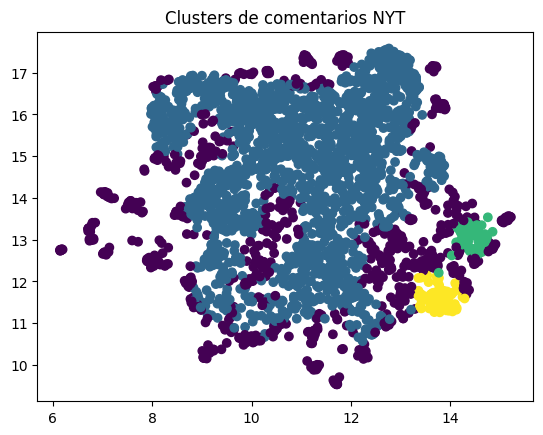

In [51]:
import matplotlib.pyplot as plt

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters)
plt.title("Clusters de comentarios NYT")
plt.show()

### 6. INTERPRETACIÓN DE TEMAS

In [52]:
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c}")
    sample = df[df["cluster"] == c]["commentBody"].head(3)
    for s in sample:
        print("-", s[:200])


Cluster -1
- After watching Hidden Figures, I can't stop thinking about how much sooner humankind would have made it to space if racism and sexism did not exist. If each person had equal opportunity and autonomy, 
- The National Gallery should be ashamed of itself. Censoring art and artists for their behavior and views is something that was perfected in Nazi Germany, Stalinist Communist Russia, Mao's Cultural Rev
- Maybe Mitt can bring integrity back to Washington.  I am a Democrat and I wish him well.  We need more Republicans like him.  

Cluster 0
- I agree that it is becoming too sweeping of a term.  <br/><br/>Tom Friedman popularized the idea that problems in the Mideast are stymied by the tribalism loyalties and prejudices that keep perpetuati
- Haiku<br/><br/>Walmart wages up...<br/>But closing 63 stores<br/>To offset wage hike.
- It is getting very ugly. Welcome to the next civil war conducted through social media. <br/><br/>Give me any time the honesty of the progressive move